In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
a = np.array([[1, 1], [2, 2], [3, 3]])

In [42]:
x = np.random.randint(1, 100, 300)
y = np.random.randint(1, 100, 300)

In [43]:
data = np.empty((300, 2))

In [44]:
for i in range(300):
    data[i][0] = x[i]
    data[i][1] = y[i]

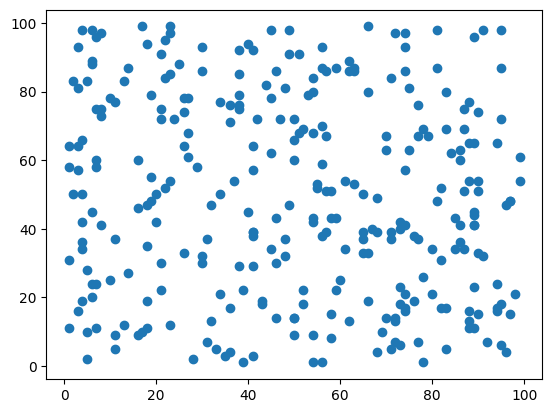

In [45]:
plt.scatter(x, y)

In [111]:
class ClusterAndCentroids:
    
    def ComputeNewCentroid(data, k, cluster):
        m, n = data.shape
        centroids = np.empty((k, n))
        for i in range(k):
            points = data[cluster == i] 
            centroids[i] = np.mean(points, axis = 0)
        return centroids

    def AssignCluster(data, centroids):
        cluster = np.empty(data.shape[0])
        for i in range(data.shape[0]):
            distance = []
            for j in range(centroids.shape[0]):
                distance.append(np.linalg.norm(data[i] - centroids[j])) # to compute square distance
            cluster[i] = np.argmin(distance) # gives the index of the min element in the array
        return cluster

    def Centroids(data, centroids, iters):
        cluster = AssignCluster(data, centroids)
        for i in range(iters):
            NewCentroid = ComputeNewCentroid(data, centroids.shape[0], cluster)
            cluster = AssignCluster(data, NewCentroid)
        return NewCentroid

In [109]:
centroids = np.array([[3, 3], [40, 60], [80, 60], [40, 80], [80, 10]])
iters = 20

In [129]:
NewCentroids = ClusterAndCentroids.Centroids(data, centroids, iters)
NewCentroids

array([[19.45614035, 23.31578947],
       [48.65116279, 51.48837209],
       [77.69811321, 75.98113208],
       [22.36363636, 80.63636364],
       [76.67901235, 23.41975309]])

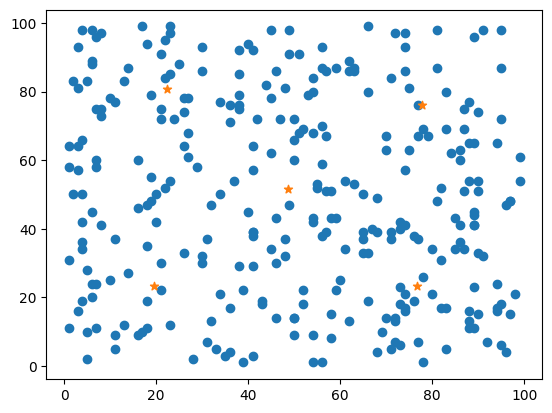

In [131]:
plt.scatter(x, y)
x_ = []
y_ = []
for i in range(NewCentroids.shape[0]):
    x_.append(NewCentroids[i][0])
    y_.append(NewCentroids[i][1])
plt.scatter(x_, y_, marker = "*")